# COVID-19 Global Vaccination Analysis
## Exploratory Data Analysis of Global Vaccination Progress

This project analyses a global COVID-19 vaccination dataset containing 86,512 records across 222 countries. 
The goal is to understand vaccination rollout progress, identify leading countries, and compare vaccine usage globally.

**Tools used:** Python, Pandas, Matplotlib
**Dataset:** COVID-19 World Vaccination Progress (Kaggle)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("country_vaccinations.csv")
df.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [2]:
print(df.columns.tolist())
print(df.shape)
df.info()

['country', 'iso_code', 'date', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'daily_vaccinations_raw', 'daily_vaccinations', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million', 'vaccines', 'source_name', 'source_website']
(86512, 15)
<class 'pandas.DataFrame'>
RangeIndex: 86512 entries, 0 to 86511
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              86512 non-null  str    
 1   iso_code                             86512 non-null  str    
 2   date                                 86512 non-null  str    
 3   total_vaccinations                   43607 non-null  float64
 4   people_vaccinated                    41294 non-null  float64
 5   people_fully_vaccinated              38802 non-null  float64
 6   daily_vaccinations_raw

In [3]:
latest = df.groupby("country")["people_fully_vaccinated_per_hundred"].max().dropna().sort_values(ascending=False).head(10)
print(latest)

country
Gibraltar               122.37
Pitcairn                100.00
United Arab Emirates     96.12
Portugal                 92.60
Brunei                   91.71
Singapore                91.04
Malta                    90.35
Chile                    90.29
Qatar                    88.50
Cayman Islands           87.80
Name: people_fully_vaccinated_per_hundred, dtype: float64


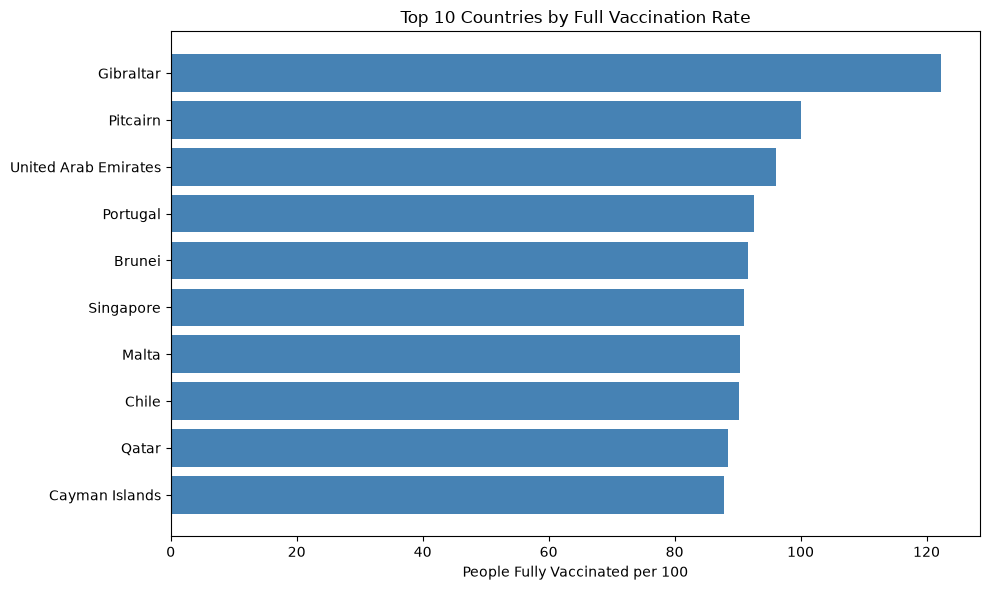

In [4]:
plt.figure(figsize=(10,6))
plt.barh(latest.index[::-1], latest.values[::-1], color="steelblue")
plt.title("Top 10 Countries by Full Vaccination Rate")
plt.xlabel("People Fully Vaccinated per 100")
plt.tight_layout()
plt.show()

Finding 1: Small Nations Lead in Vaccination Rates
Gibraltar reports over 100% vaccination — possible due to vaccinating non-residents. 
UAE, Portugal, and Brunei lead among larger nations, all exceeding 90% full vaccination rate.

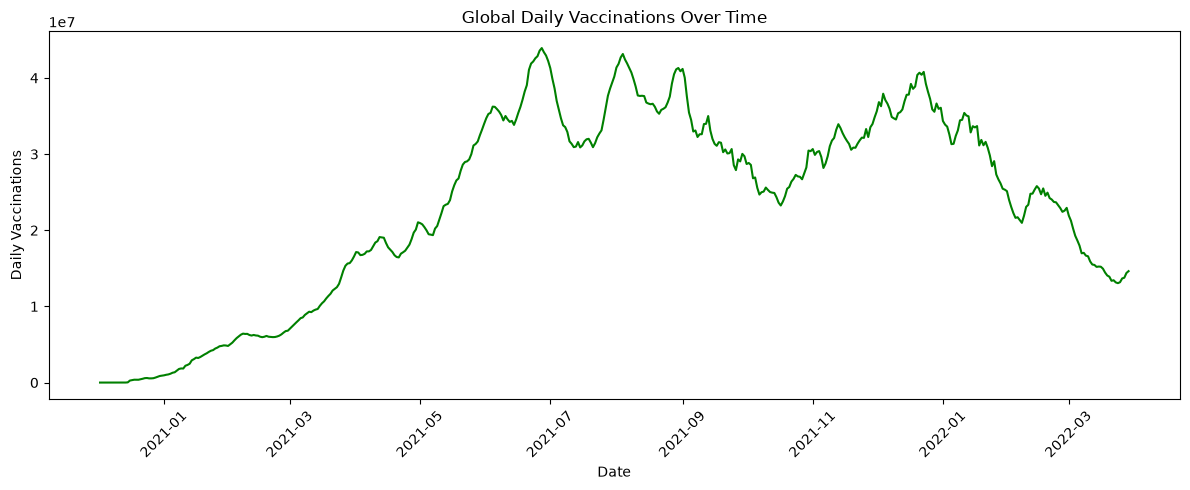

In [5]:
df["date"] = pd.to_datetime(df["date"])
global_daily = df.groupby("date")["daily_vaccinations"].sum()

plt.figure(figsize=(12,5))
plt.plot(global_daily.index, global_daily.values, color="green")
plt.title("Global Daily Vaccinations Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Vaccinations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding 2: Global Rollout Accelerated Through 2021
Daily vaccinations surged sharply in early 2021 as programmes launched worldwide. 
The rollout peaked mid-2021 before gradually declining as populations reached saturation.

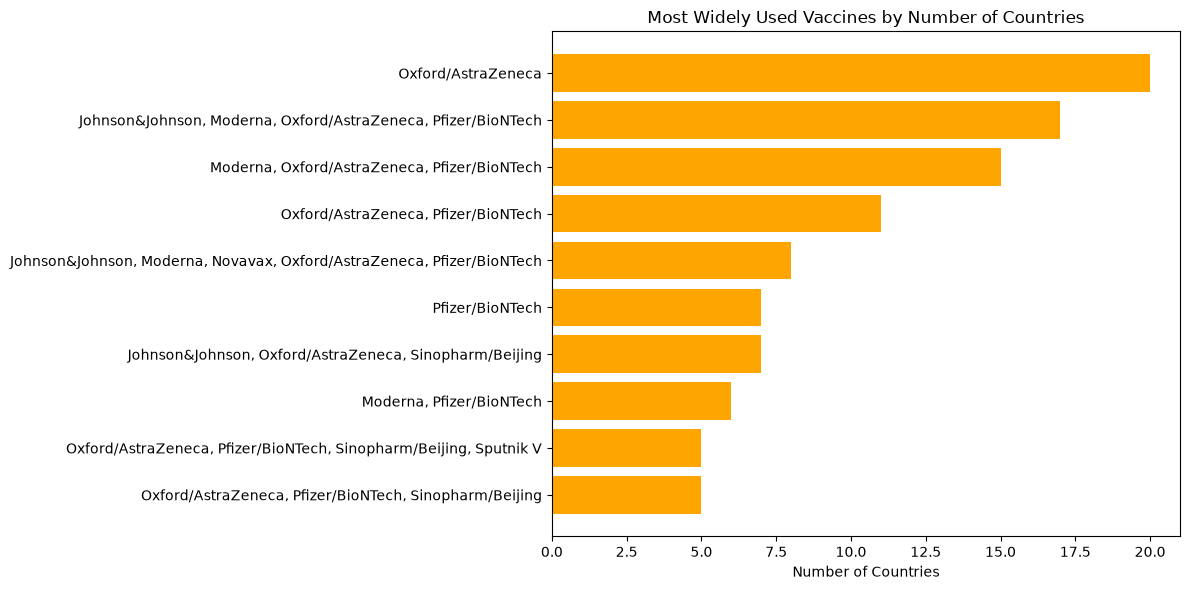

In [6]:
vaccine_counts = df.groupby("vaccines")["country"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(vaccine_counts.index[::-1], vaccine_counts.values[::-1], color="orange")
plt.title("Most Widely Used Vaccines by Number of Countries")
plt.xlabel("Number of Countries")
plt.tight_layout()
plt.show()

### Finding 3: A Small Number of Vaccines Dominated Globally
A handful of vaccine combinations were adopted by the majority of countries. 
This reflects both supply availability and international procurement agreements during the pandemic.

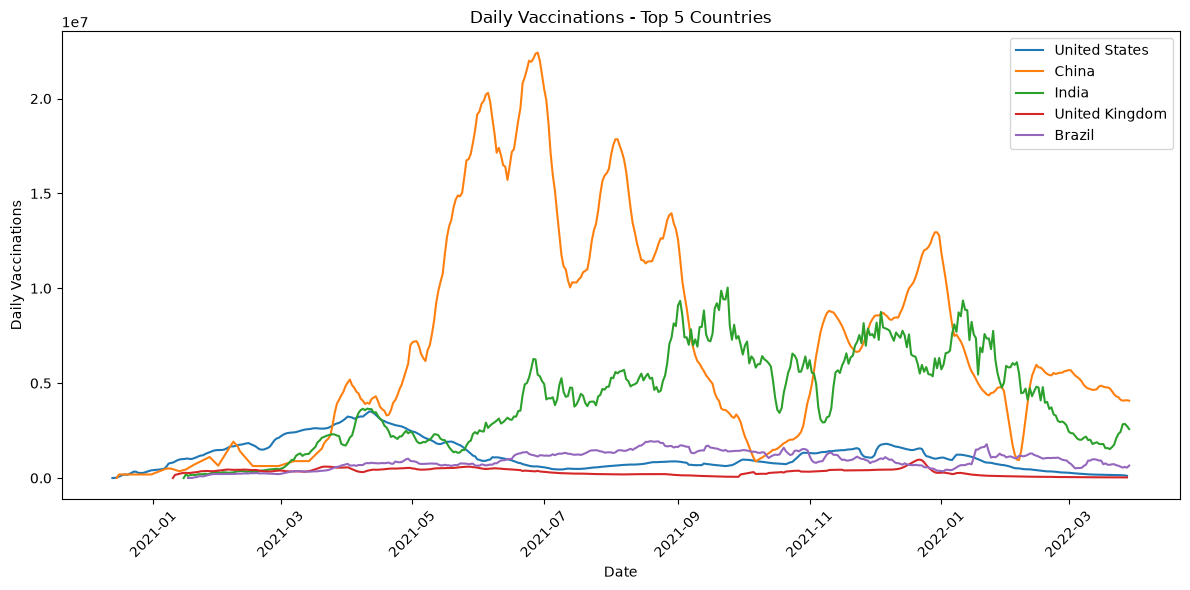

In [7]:
top_countries = ["United States", "China", "India", "United Kingdom", "Brazil"]

plt.figure(figsize=(12,6))
for country in top_countries:
    country_data = df[df["country"] == country].groupby("date")["daily_vaccinations"].sum()
    plt.plot(country_data.index, country_data.values, label=country)

plt.title("Daily Vaccinations - Top 5 Countries")
plt.xlabel("Date")
plt.ylabel("Daily Vaccinations")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding 4: US and India Led in Raw Daily Vaccinations
The United States and India drove the highest daily vaccination numbers due to their large populations. 
The UK showed a strong early rollout relative to its population size.

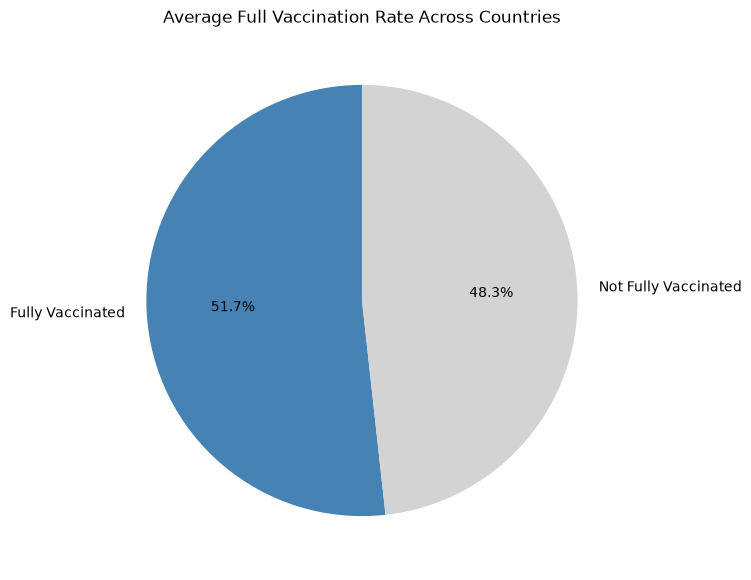

In [8]:
latest_per_country = df.groupby("country")["people_fully_vaccinated_per_hundred"].max().dropna()

avg_vaccinated = latest_per_country.mean()
not_vaccinated = 100 - avg_vaccinated

labels = ["Fully Vaccinated", "Not Fully Vaccinated"]
sizes = [avg_vaccinated, not_vaccinated]
colors = ["steelblue", "lightgrey"]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Average Full Vaccination Rate Across Countries")
plt.show()

### Finding 5: A Significant Portion of the World Remains Unvaccinated
Despite rapid progress, a large share of the global population has not been fully vaccinated. 
This reflects inequalities in vaccine access between high and low income countries.

## Key Takeaways

- **Small nations** achieved the highest vaccination rates, often exceeding 90%
- **Global rollout peaked in mid-2021** before declining as high-income countries reached saturation
- **A small number of vaccines** were adopted by the majority of countries globally
- **US and India** led in raw daily vaccination numbers due to population size
- **Significant global inequality** remains — many low-income countries lag far behind

## Recommendations

1. International organisations should prioritise vaccine distribution to low-income countries
2. Governments should analyse which vaccine combinations achieved the fastest rollout
3. Future pandemic preparedness should include pre-agreed global supply chain agreements